# DDA - Label-Free

This tutorial demonstrates how to analyze label-free quantification (LFQ) data from data-dependent acquisition (DDA) using the `msmu` package.

## Data Preparation

Original dataset is from [PXD012986](https://www.ebi.ac.uk/pride/archive/projects/PXD012986) (Uszkoreit _et al_., 2022) and search was performed with [`Sage` v0.14.7](https://github.com/lazear/sage/tree/v0.14.7).

For demonstration purposes, the example dataset was reduced to six samples and a total of 5,000 PSMs.


In [1]:
base_dir = "https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/sage_lfq"
sage_idents = f"{base_dir}/sage/results.sage.tsv"
sage_quants = f"{base_dir}/sage/lfq.tsv"
sdrf = f"{base_dir}/meta.sdrf.tsv"

## Load Required Packages

> If you haven't installed the `msmu` package yet, please follow the [installation guide](../../installation/).


In [2]:
import msmu as mm
import plotly.io as pio

pio.renderers.default = "png"

## Read Data

You can read data from various proteomics software outputs. Below are examples for `Sage`, `MaxQuant`, and `FragPipe` formats.

For this tutorial, we will use the `Sage` output as an example.

`read_sage()` function reads the `Sage` output files (`lfq.tsv`, `results.sage.tsv`) and creates modalities at MuData object.


In [3]:
# Sage format
mdata = mm.read_sage(identification_file=sage_idents, quantification_file=sage_quants, label="label_free")

# MaxQuant format
# mdata = mm.read_maxquant(identification_file="path_to_maxquant_output", label="label_free", acquisition="dda")

# FragPipe format
# mdata = mm.read_fragpipe(identification_file="path_to_fragpipe_output", label="label_free", acquisition="dda")

# Sample metadata from the SDRF: keep the table on the container, then project it onto obs
mdata = mm.pp.attach_sdrf(mdata, sdrf)
mdata = mm.pp.apply_sdrf_to_obs(mdata)

mdata.obs

# Without an SDRF, add_meta() joins any table (DataFrame, csv, tsv, parquet) onto obs instead:
# mdata = mm.pp.add_meta(mdata, sdrf, format="sdrf", metadata_on="assay name")

INFO - Validating SDRF metadata for https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/sage_lfq/meta.sdrf.tsv.
INFO - SDRF validation succeeded for https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/sage_lfq/meta.sdrf.tsv.


,source name,characteristics[organism],characteristics[organism part],characteristics[cell line],characteristics[cell type],characteristics[cellosaurus accession],characteristics[cellosaurus name],characteristics[disease],characteristics[biological replicate],assay name,technology type,comment[proteomexchange accession number],comment[proteomics data acquisition method],comment[fraction identifier],comment[technical replicate],comment[label],comment[instrument],comment[cleavage agent details],factor value[condition]
QExHF04026,G1-1,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,1,QExHF04026,proteomic profiling by mass spectrometry,PXD012986,data-dependent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G1
QExHF04028,G2-1,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,1,QExHF04028,proteomic profiling by mass spectrometry,PXD012986,data-dependent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G2
QExHF04036,G1-2,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,2,QExHF04036,proteomic profiling by mass spectrometry,PXD012986,data-dependent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G1
QExHF04038,G2-2,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,2,QExHF04038,proteomic profiling by mass spectrometry,PXD012986,data-dependent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G2
QExHF04046,G1-3,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,3,QExHF04046,proteomic profiling by mass spectrometry,PXD012986,data-dependent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G1
QExHF04048,G2-3,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,3,QExHF04048,proteomic profiling by mass spectrometry,PXD012986,data-dependent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G2


### Saving Raw MuData Object

After reading the search output, saving the MuData object as an `h5mu` file is recommended for future use.


In [6]:
mdata.write_h5mu("dda_lfq_PXD012986_raw.h5mu")

## Handling PSM level

### Filtering - PSM

You can filter the data based on the column values, such as q-value.
You can also filter on the flags the reader records, such as `contaminant`, or on string containment.

Filtering is split into two steps: first, you mark a filter condition using `mm.pp.add_filter()`, and then you apply the filter using `mm.pp.apply_filter()`.

Here, we keep protein groups with q-value < 0.01.


In [4]:
mdata = mm.pp.add_filter(mdata, modality="psm", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="psm")

mdata

INFO - Applying var filters for psm: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 7914
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
  uns:	'_cmd', 'sdrf'
  2 modalities
    psm:	6 × 4336
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'filter', 'decoy_filter'
      varm:	'search_result', 'filter'
      layers:	None
    peptide:	6 × 3578
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      uns:	'level'
      layers:	None

## Handling peptide level

### Summarization - peptide

You can summarize psm-level data to peptide-level data using the `mm.pp.to_peptide()` function.


In [5]:
mdata = mm.pp.to_peptide(mdata)

INFO - Peptide-level identifications: 3683 (3664 at 1% FDR)
INFO - Using existing peptide quantification data.


### Filtering - peptide


In [6]:
mdata = mm.pp.add_filter(mdata, modality="peptide", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="peptide", on="var")

mdata

INFO - Applying var filters for peptide: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 8000
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
  uns:	'_cmd', 'sdrf'
  2 modalities
    psm:	6 × 4336
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'filter', 'decoy_filter'
      varm:	'search_result', 'filter'
      layers:	None
    peptide:	6 × 3664
      var:	'peptide', 'proteins', 'stripped_peptide', 'count_psm', 'PEP', 'q_value'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
      layers:	None

### Normalization

Here, we log2 transform and normalize the data at the peptide level.

Median centering normalization is applied using `mm.pp.normalize()` function.


In [7]:
mdata = mm.pp.log2_transform(mdata, modality="peptide")
mdata = mm.pp.normalize(mdata, modality="peptide", method="median")

### Protein inference

You can infer protein-level data from peptide-level data using the `mm.pp.infer_protein()` function.


In [8]:
mdata = mm.pp.infer_protein(mdata)

INFO - Starting protein inference
INFO - Initial proteins: 3721
INFO - Removed indistinguishable: 1624
INFO - Removed subsettable: 559
INFO - Removed subsumable: 2
INFO - Total protein groups: 1536


## Handling protein level

### Summarization - protein

You can summarize peptide-level data to protein-level data using the `mm.pp.to_protein()` function.

As default, top 3 peptides within protein group can be used for protein group quantification aggregation. If top_n is None, all peptides will be used.


In [9]:
mdata = mm.pp.to_protein(mdata, top_n=3, rank_method="median_intensity")

INFO - Applying var filters for peptide: ['q_value_lt_0.01', 'peptide_type_eq_unique']
INFO - Protein-level identifications: 1501 (1475 at 1% FDR)


### Filtering - protein


In [10]:
mdata = mm.pp.add_filter(mdata, modality="protein", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="protein", on="var")

mdata

INFO - Applying var filters for protein: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 9475
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
  uns:	'_cmd', 'sdrf'
  3 modalities
    psm:	6 × 4336
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'filter', 'decoy_filter'
      varm:	'search_result', 'filter'
      layers:	None
    peptide:	6 × 3664
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'peptide', 'proteins', 'stripped_peptide', 'count_psm', 'PEP', 'q_value', 'protein_group', 'peptide_type'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
      layers:	None
    protein:	6 × 1475
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'count_psm', 'count_stripped_peptide', 'PEP', 'q_value'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
      layers:	None

## Visualization

### ID plot


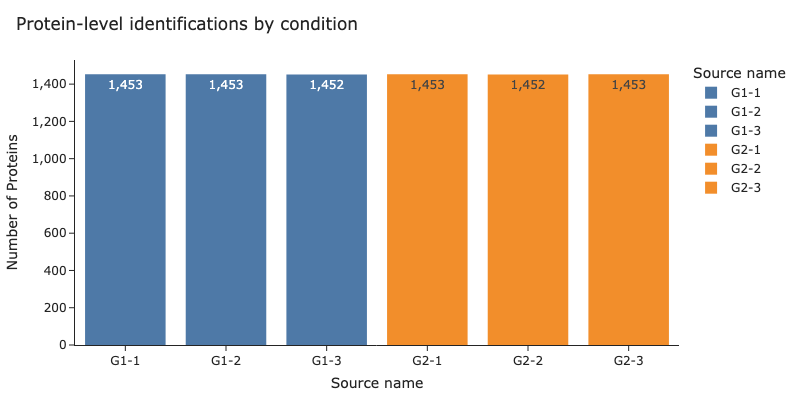

In [11]:
mm.pl.plot_id(mdata, modality="protein", colorby="factor value[condition]").update_layout(width=800, height=400, title="Protein-level identifications by condition")

### Intensity distribution plot


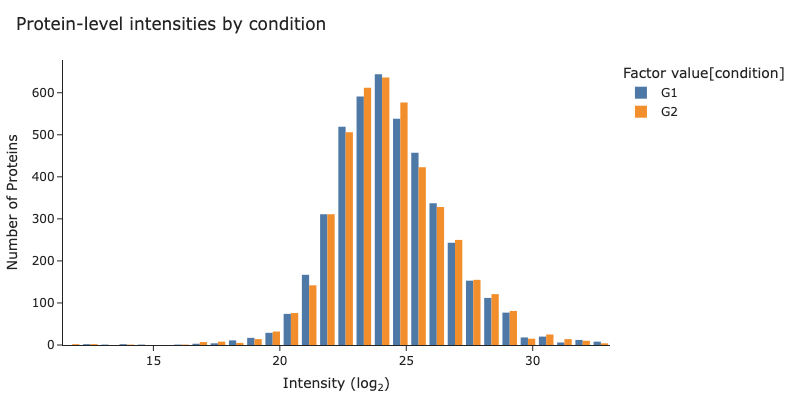

In [12]:
mm.pl.plot_intensity(mdata, modality="protein", groupby="factor value[condition]").update_layout(width=800, height=400, title="Protein-level intensities by condition")

## Saving Processed MuData Object

You can save MuData object into an `h5mu` file.
This allows you to easily reload the processed data in future sessions without repeating the entire analysis pipeline.


In [16]:
mdata.write_h5mu("dda_lfq_PXD012986.h5mu")

## Citation

> Uszkoreit, J., Barkovits, K., Pacharra, S., Pfeiffer, K., Steinbach, S., Marcus, K., & Eisenacher, M. (2022). Dataset containing physiological amounts of spike-in proteins into murine C2C12 background as a ground truth quantitative LC-MS/MS reference. _Data in Brief_, 43, 108435.

> Lazear, M. R. (2023). Sage: an open-source tool for fast proteomics searching and quantification at scale. _Journal of Proteome Research_, 22(11), 3652-3659.
